<a href="https://colab.research.google.com/github/Alilson2/Projeto_IA/blob/main/ProjetoIA_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr # Ler arquivos netcdf
from google.colab import drive
import seaborn as sns

import matplotlib.patches as mpatches # Desenhar geometria em um mapa

In [2]:
import os
import xarray as xr

# --- Clonar repositório se não existir ---
if not os.path.exists("Projeto_IA"):
    !git clone https://github.com/Alilson2/Projeto_IA.git
else:
    print("📁 Repositório 'Projeto_IA' já existe — pulando o clone.")

# --- Verificar se a pasta foi criada ---
if not os.path.exists("Projeto_IA"):
    raise FileNotFoundError("❌ A pasta 'Projeto_IA' não foi encontrada. O clone pode ter falhado.")
else:
    print("\n✅ Repositório clonado com sucesso!\n")
    print("Arquivos dentro da pasta Projeto_IA:\n", os.listdir("Projeto_IA"))

# --- Localizar arquivos .nc ---
arquivos_nc = [f for f in os.listdir("Projeto_IA") if f.endswith(".nc")]
if not arquivos_nc:
    raise FileNotFoundError("❌ Nenhum arquivo .nc encontrado na pasta Projeto_IA!")
else:
    print("\n📂 Arquivo(s) NetCDF encontrado(s):")
    for f in arquivos_nc:
        print(" -", f)

# --- Montar lista de caminhos ---
ARQUIVO = [os.path.join("Projeto_IA", f) for f in arquivos_nc]

# --- Função para corrigir longitude ---
def corrigir_longitude(ds):
    for coord in ["longitude", "lon"]:
        if coord in ds.coords:
            ds = ds.assign_coords({coord: ((ds[coord] + 180) % 360) - 180})
            ds = ds.sortby(coord)
    return ds

# --- Abrir arquivos com segurança (nova sintaxe) ---
try:
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='by_coords',
        parallel=True,           # usa múltiplos núcleos
        preprocess=corrigir_longitude,
        combine_attrs='override' # 🟢 substitui o antigo compat='override'
    )
except ValueError as e:
    print("\n⚠️ Erro na combinação — tentando modo 'nested' (concat por tempo)...")
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='nested',
        concat_dim='valid_time',  # ajuste se sua dimensão temporal tiver outro nome
        parallel=True,
        preprocess=corrigir_longitude,
        combine_attrs='override'
    )

print("\n✅ Dataset carregado com sucesso!\n")
dados

Cloning into 'Projeto_IA'...
remote: Enumerating objects: 236, done.
remote: Counting objects: 100% (236/236), done.
remote: Compressing objects: 100% (234/234), done.
remote: Total 236 (delta 58), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (236/236), 162.93 MiB | 17.48 MiB/s, done.
Resolving deltas: 100% (58/58), done.

✅ Repositório clonado com sucesso!

Arquivos dentro da pasta Projeto_IA:
 ['(NOVEMBRO 2021-16 a 30).nc', '(JULHO 2023 - 1a15) 6fdadb7142db0ca316d72f4c3cf60eec.nc', 'MAR 2022 - 1a31.nc', '(JUNHO 2023 - 1a15) a6b209ca9f73a07c7a9f05f4683b0ce0.nc', '(JANEIRO 2023 - 16a31) 94ce3bca85fad1ca87acdd2bfbff170b.nc', '(JAN 2020-16 a 31).nc', '(OUTUBRO 2023 - 16a31).nc', 'DEZ 2022 - 16a31.nc', 'NOV 2022 - 16a30.nc', 'DEZ 2022 - 1a15.nc', 'Cópia_de_ProjetoIA_ver_David.ipynb', '(OUTUBRO 2024 - 1a15) c32ddd8a51679c9adea94613420cc6d5.nc', '(JUL 2020-25 a 31).nc', '(JULHO 2024 - 16a31) bbaf0148256b34f39eea38f68c677b6e.nc', 'AGO 2022 - 1a15.nc', '(FEVEREIRO 2023 -

/tmp/ipython-input-2195183609.py:39: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-2195183609.py:39: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(



⚠️ Erro na combinação — tentando modo 'nested' (concat por tempo)...


/tmp/ipython-input-2195183609.py:48: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-2195183609.py:48: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(



✅ Dataset carregado com sucesso!



<xarray.Dataset> Size: 464MB
Dimensions:     (valid_time: 43848, latitude: 12, longitude: 22)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 351kB 2021-11-16 ... 2020-05-24T2...
  * latitude    (latitude) float64 96B -24.2 -24.2 -24.1 ... -23.4 -23.3 -23.2
  * longitude   (longitude) float64 176B -47.2 -47.19 -47.1 ... -46.2 -46.19
    number      int64 8B 0
    expver      (valid_time) <U4 702kB dask.array<chunksize=(360,), meta=np.ndarray>
Data variables:
    d2m         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    slhf        (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    sshf        (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    ssrd        (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    e           (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    sp          (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-26T20:47 GRIB to CDM+CF via cfgrib-0.9.1...

In [27]:
df = dados.to_dataframe()
df = df.dropna()

# --- 2️⃣ Verificar se há a coordenada temporal ---
if "valid_time" not in dados.coords:
    raise ValueError("❌ O dataset não contém uma coordenada temporal chamada 'valid_time'.")

# --- 3️⃣ Converter o eixo temporal para pandas.DatetimeIndex ---
tempo = pd.to_datetime(dados["valid_time"].values)

# --- 4️⃣ Criar DataFrame com componentes temporais ---
df_tempo = pd.DataFrame({
    "timestamp": tempo,
    "timestamp_segundos": tempo.view("int64"),   # segundos desde 1970
    "ano": tempo.year,
    "mes": tempo.month,
    "dia": tempo.day,
    "hora": tempo.hour,
    "minuto": tempo.minute,
    "segundo": tempo.second,
    "dia_semana": tempo.dayofweek,
    "dia_do_ano": tempo.dayofyear
})

#print(df_tempo.head())

# Exemplo: seleciona uma variável e um período
# Sort the dataset by valid_time before slicing
dados_sorted = dados.sortby('valid_time')
dados_filtrado = dados_sorted

# Converte para pandas sem estourar RAM
df_panda = dados_filtrado.to_dataframe().reset_index()
df_panda = df_panda.dropna()

# Junta com df_tempo
df_final = pd.merge(
    df_panda,
    df_tempo,
    left_on='valid_time',
    right_on='timestamp',
    how='left'
)



In [110]:
import numpy as np
import pandas as pd
df_panda = df_final
def calcula_vapor_umidade(data):
    # Temperatura e ponto de orvalho em Celsius
    t2m_celsius = data["t2m"] - 273.15
    d2m_celsius = data["d2m"] - 273.15

    # 1) Pressão de vapor de saturação (es) em Pa
    es = 610.94 * np.exp(17.625 * t2m_celsius / (243.04 + t2m_celsius))

    # 2) Pressão de vapor real (ev) em Pa
    ev = 610.94 * np.exp(17.625 * d2m_celsius / (243.04 + d2m_celsius))

    # 3) Umidade Relativa (%)
    RH = 100 * ev / es

    # 4) Déficit de Pressão de Vapor (kPa)
    VPD = (es - ev) / 1000

    # Retorna como DataFrame para fácil concatenação
    return pd.DataFrame({
        "es": es,
        "ev": ev,
        "RH": RH,
        "VPD": VPD
    })

# --- Aplicar ao DataFrame original ---
resultados = calcula_vapor_umidade(df_panda)

# Adiciona novas colunas ao df_panda
df_panda = pd.concat([df_panda.reset_index(drop=True), resultados.reset_index(drop=True)], axis=1)

'''O_lim = -46.84
L_lim = -46.36
N_lim = -23.36
S_lim = -24

ind = np.where((df_panda['latitude'] >= S_lim) & (df_panda['latitude'] <= N_lim) & (df_panda['longitude'] <= L_lim) & (df_panda['longitude'] >= O_lim))[0]
df_panda = df_panda.iloc[ind].reset_index()'''

"O_lim = -46.84\nL_lim = -46.36\nN_lim = -23.36\nS_lim = -24\n\nind = np.where((df_panda['latitude'] >= S_lim) & (df_panda['latitude'] <= N_lim) & (df_panda['longitude'] <= L_lim) & (df_panda['longitude'] >= O_lim))[0]\ndf_panda = df_panda.iloc[ind].reset_index()"

In [111]:
#RODE APENAS SE NÃO TIVER OS DADOS PRONTOS
from tqdm import tqdm
import numpy as np
import pandas as pd


def criar_dados(df_panda):

    variaveis = ['d2m', 't2m', 'u10', 'v10', 'slhf', 'sshf', 'ssrd',
                 'sp', 'e', 'tp', 'es', 'ev', 'RH', 'VPD']

    # Se quiser somar algumas variáveis, liste-as aqui
    vars_sum = []   # ex: ['e', 'tp']

    # Estatísticas a aplicar nas variáveis normais
    estatisticas = {
        "mean": "mean",
        "min": "min",
        "max": "max",
        "std": "std",
        "median": "median"
    }

    grouped = df_panda.groupby("valid_time")

    resultados = {}

    for var in variaveis:
        if var not in vars_sum:
            for label, func in estatisticas.items():
                resultados[f"{var}_{label}"] = grouped[var].agg(func)

        else:
            # Apenas SUM para variáveis definidas em vars_sum
            resultados[f"{var}_sum"] = grouped[var].sum()

    df_resumo = pd.concat(resultados, axis=1).reset_index()

    return df_resumo



In [112]:
#RODE APENAS SE NÃO TIVER OS DADOS PRONTOS
df_resumo = criar_dados(df_panda)
df_resumo['valid_time'] = pd.to_datetime(df_resumo['valid_time'])
df_resumo['data'] = df_resumo['valid_time'].dt.date


def agregar_diario(df_resumo):

    # Mapeia sufixos → operações
    mapa_aggs = {
        "_mean": "mean",
        "_min": "min",
        "_max": "max",
        "_sum": "sum",
        "_std": "std",
        "_median": "median"
    }

    aggs = {}

    # Detecta automaticamente quais colunas devem ser agregadas
    for col in df_resumo.columns:
        for suf, func in mapa_aggs.items():
            if col.endswith(suf):
                aggs[col] = func
                break  # evita verificar outros sufixos desnecessariamente

    df_diario = df_resumo.groupby("data").agg(aggs).reset_index()

    return df_diario

df_diario = agregar_diario(df_resumo)

df_diario['data'] = pd.to_datetime(df_diario['data'])
df_diario['mes'] = df_diario['data'].dt.month

df_diario['tp_sum'] = df_diario['tp_mean']
df_diario = df_diario.drop(['tp_mean', 'tp_min', 'tp_max', 'tp_std', 'tp_median'], axis=1)

df_diario.to_csv('df_diario.csv', index=False, encoding='utf-8')

In [113]:
df_diario

,data,d2m_mean,d2m_min,d2m_max,d2m_std,d2m_median,t2m_mean,t2m_min,t2m_max,t2m_std,...,RH_max,RH_std,RH_median,VPD_mean,VPD_min,VPD_max,VPD_std,VPD_median,mes,tp_sum
0,2020-01-01,292.666779,287.502930,300.117676,0.797543,292.117371,298.356293,291.257935,305.379517,0.188835,...,99.761469,3.488575,67.927666,0.988804,0.006171,2.871634,0.167576,1.045921,1,0.000125
1,2020-01-02,293.406097,289.850098,299.291992,0.572163,293.026855,296.250916,292.527832,301.236694,0.146220,...,99.467196,2.447660,85.805080,0.456947,0.012338,1.377248,0.080116,0.391319,1,0.010732
2,2020-01-03,292.296295,290.121094,296.039429,0.104259,291.776062,294.345428,291.699341,299.012939,0.080596,...,99.955850,1.173854,90.049386,0.303775,0.001040,1.110049,0.042944,0.229274,1,0.003753
3,2020-01-04,291.970093,289.903931,296.244019,0.157321,291.579987,293.869171,290.257568,298.851929,0.207538,...,99.653280,1.570474,91.119995,0.279918,0.007672,1.088167,0.053765,0.200112,1,0.005489
4,2020-01-05,292.203278,289.977539,295.422302,0.173296,291.882874,294.359039,290.072388,300.247314,0.204280,...,99.899298,0.712792,91.521649,0.336362,0.002168,1.133866,0.032553,0.207258,1,0.004167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-27,293.573822,291.736938,297.274414,0.172451,293.209534,294.762817,292.627441,299.182007,0.196242,...,99.979259,1.087691,94.186521,0.185341,0.000492,0.708451,0.040694,0.148603,12,0.011470
1823,2024-12-28,293.463440,291.095581,299.762207,0.243634,293.057556,295.803070,292.189819,301.212708,0.138495,...,99.234654,2.589186,89.791891,0.382776,0.018421,1.321146,0.095578,0.264680,12,0.003536
1824,2024-12-29,292.879517,290.006592,298.671753,0.283119,292.377258,294.771759,290.074951,300.463867,0.206860,...,99.822453,2.471505,90.271189,0.297529,0.003849,1.298997,0.087666,0.246879,12,0.002211
1825,2024-12-30,292.186340,290.180054,296.725220,0.123837,291.671783,294.175354,290.299072,299.284668,0.170468,...,99.527032,1.816502,89.558831,0.300020,0.009406,1.026971,0.058910,0.248588,12,0.003688


In [3]:
url = 'https://raw.githubusercontent.com/Alilson2/Projeto_IA/main/df_diario.csv'
df_diario = pd.read_csv(url)

In [114]:
ind_per = int(0.8*len(df_diario))
df_diario_train = df_diario.iloc[:ind_per].copy()
df_diario_test = df_diario.iloc[ind_per:].copy()

df_diario_train['tp_sum'] = df_diario_train['tp_sum'].shift(-1)
df_diario_train = df_diario_train.dropna(subset=['tp_sum'])
df_diario_test['tp_sum'] = df_diario_test['tp_sum'].shift(-1)
df_diario_test = df_diario_test.dropna(subset=['tp_sum'])

In [115]:
def separar_dados(df_diario, limiar = 0.0005):
  X = df_diario.drop(['data', 'tp_sum'], axis=1)
  y = df_diario['tp_sum'].copy()

  ind_sem_chuva = np.where(y <= limiar)[0]
  ind_com_chuva = np.where(y > limiar)[0]

  y.iloc[ind_sem_chuva] = 0
  y.iloc[ind_com_chuva] = 1

  return X, y

In [116]:
from sklearn.preprocessing import StandardScaler
X_test_raw, y_test = separar_dados(df_diario_test)
X_train_raw, y_train = separar_dados(df_diario_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.fit_transform(X_test_raw)

In [117]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

importances = model.feature_importances_
feature_names = X_train_raw.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

In [118]:
def report(y_test, y_pred, feature_importance_df):
  print("Acurácia:", accuracy_score(y_test, y_pred))
  print("\nMatriz de confusão:\n", confusion_matrix(y_test, y_pred))
  print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))
  plt.figure(figsize=(12, 8))
  sns.barplot(x='importance', y='feature', data=feature_importance_df)
  plt.title('Feature Importances from Random Forest Classifier')
  plt.xlabel('Importance')
  plt.ylabel('Feature')
  plt.show()

Acurácia: 0.7863013698630137

Matriz de confusão:
 [[135  52]
 [ 26 152]]

Relatório de classificação:
               precision    recall  f1-score   support

         0.0       0.84      0.72      0.78       187
         1.0       0.75      0.85      0.80       178

    accuracy                           0.79       365
   macro avg       0.79      0.79      0.79       365
weighted avg       0.79      0.79      0.79       365



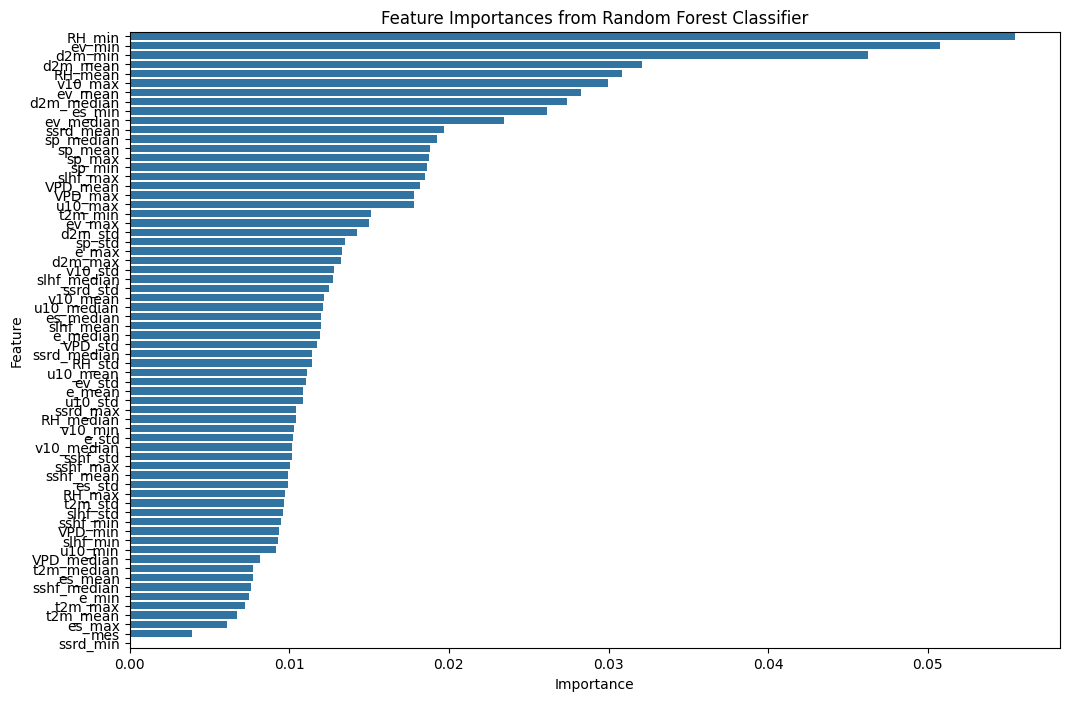

In [119]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
report(y_test, y_pred, feature_importance_df)

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns


33


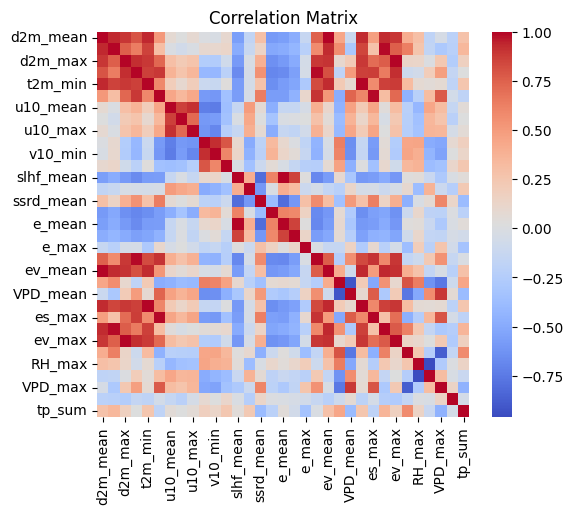

In [48]:
df_diario1 = df_diario.drop(['data'], axis=1)
correlation_matrix = df_diario1.corr()
print(len(df_diario1.keys()))


# Create a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

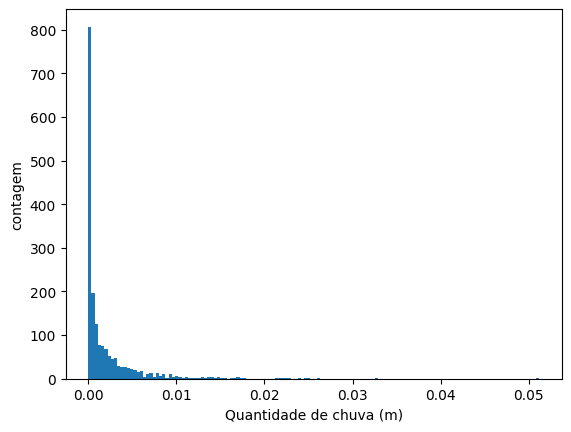

In [107]:
plt.hist(df_diario['tp_sum'], 'auto')
plt.ylabel('contagem')
plt.xlabel('Quantidade de chuva (m)')
plt.show()

In [50]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', verbose=10)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV 1/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 1/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.832 total time=   1.4s
[CV 2/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 2/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.736 total time=   0.7s
[CV 3/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 3/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.812 total time=   0.7s
[CV 4/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 4/5; 1/162] END max_depth=None, max

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=10)

In [120]:
model = RandomForestClassifier(min_samples_leaf=4, n_estimators = 300, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [121]:
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusão:\n", confusion_matrix(y_test, y_pred))
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))

Acurácia: 0.7945205479452054

Matriz de confusão:
 [[136  51]
 [ 24 154]]

Relatório de classificação:
               precision    recall  f1-score   support

         0.0       0.85      0.73      0.78       187
         1.0       0.75      0.87      0.80       178

    accuracy                           0.79       365
   macro avg       0.80      0.80      0.79       365
weighted avg       0.80      0.79      0.79       365



In [139]:
def PCA_model(X, plotar=False, printar = False):
  pca = PCA()
  pca.fit(X)
  expl = pca.explained_variance_ratio_
  svalues = pca.singular_values_
  x = pca.transform(X)
  explainability = pca.explained_variance_ratio_.cumsum()
  factors = np.arange(1,X.shape[1]+1,1)
  if plotar:
    plt.scatter(factors,explainability)
    plt.hlines(0.9,0,20,'r')
    plt.xlabel('Número de componentes')
    plt.ylabel('Explicabilidade dos dados')
  p = factors[explainability<0.9].max()+1
  if p<2:
      p=2
  if printar:
    print('90% dos dados são explicados com as ' + str(p) + ' componentes.')
  pca = PCA(n_components=p)
  pca.fit(X)
  x = pca.transform(X)
  x = pd.DataFrame(x, columns=[f"PC{i+1}" for i in range(x.shape[1])])
  nomes_atributos = x.keys()
  return x, nomes_atributos


In [153]:
from sklearn.decomposition import PCA
#x_pca, nomes =PCA_model(StandardScaler().fit_transform(df_diario.drop('data', axis=1)))
x_pca_train, nomes =PCA_model(StandardScaler().fit_transform(X_train_raw))
x_pca_test, nomes =PCA_model(StandardScaler().fit_transform(X_test_raw))

In [154]:
model = RandomForestClassifier( random_state=42)
model.fit(x_pca_train, y_train)
y_pred = model.predict(x_pca_test)

Acurácia: 0.7698630136986301

Matriz de confusão:
 [[129  58]
 [ 26 152]]

Relatório de classificação:
               precision    recall  f1-score   support

         0.0       0.83      0.69      0.75       187
         1.0       0.72      0.85      0.78       178

    accuracy                           0.77       365
   macro avg       0.78      0.77      0.77       365
weighted avg       0.78      0.77      0.77       365



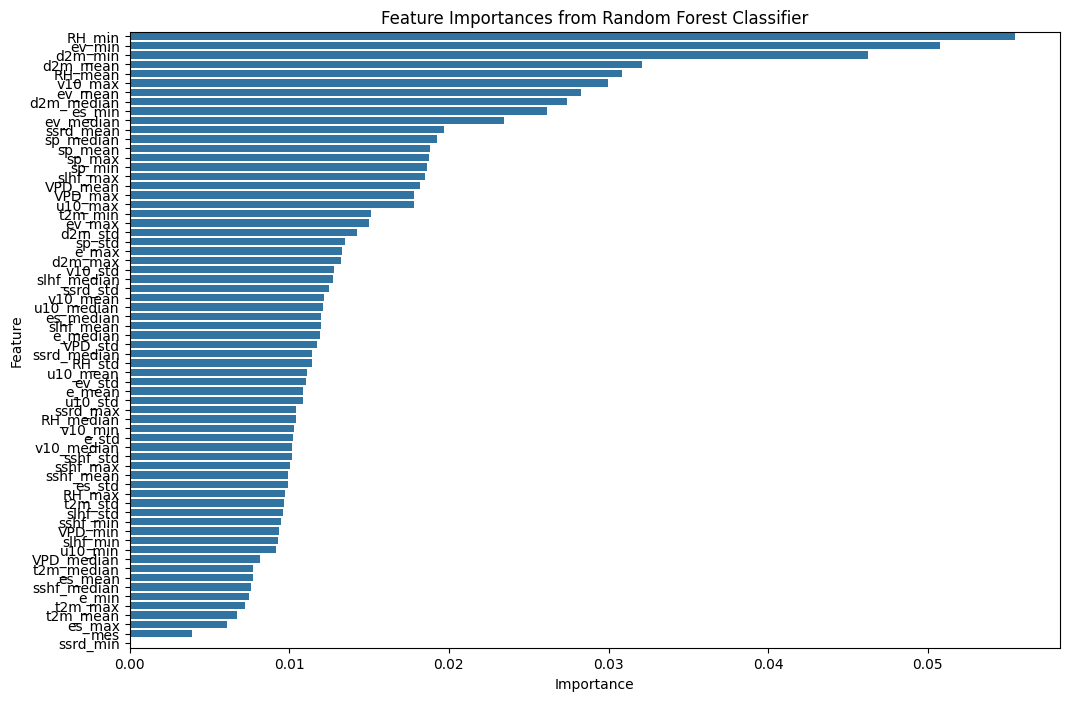

In [155]:
report(y_test, y_pred, feature_importance_df)

In [156]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', verbose=10)
grid_search.fit(x_pca_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV 1/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 1/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.784 total time=   1.6s
[CV 2/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 2/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.771 total time=   0.9s
[CV 3/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 3/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.791 total time=   1.8s
[CV 4/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 4/5; 1/162] END max_depth=None, max

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=10)

Acurácia: 0.7698630136986301

Matriz de confusão:
 [[130  57]
 [ 27 151]]

Relatório de classificação:
               precision    recall  f1-score   support

         0.0       0.83      0.70      0.76       187
         1.0       0.73      0.85      0.78       178

    accuracy                           0.77       365
   macro avg       0.78      0.77      0.77       365
weighted avg       0.78      0.77      0.77       365



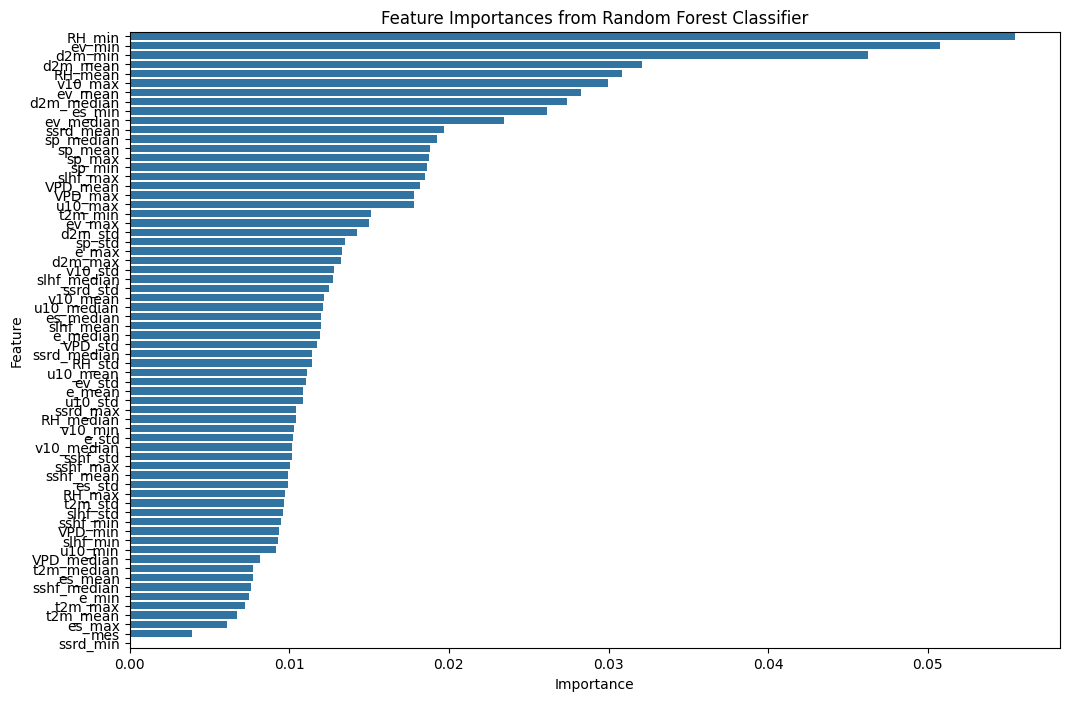

In [159]:
model = RandomForestClassifier( min_samples_split=10, n_estimators=200, random_state=42)
model.fit(x_pca_train, y_train)
y_pred = model.predict(x_pca_test)

'''importances = model.feature_importances_
feature_names = X_train_raw.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)'''

report(y_test, y_pred, feature_importance_df)